# Especialização em Análise de Dados no Futebol — 2026
## FOOTURE ACADEMY — DESAFIO FINAL
Competição: Campeonato Brasileiro Série A \
Temporada: 2025 \
Posição Analisada: Zagueiro \
Data: Janeiro/2026 \
Responsável: Daniel Alves Pinho

> #### Objetivos:
> 1. Criação de uma métrica autoral para avaliação de jogadores.
> 2. Análise de Mercado e Lista de Reforços (Scout)

####**Parte 1: Criação de Métrica Autoral Para Avaliação de Jogadores**
*1.1. Importação de bilbiotecas*
> i. Vamos importar as bibliotecas do Python cujas funções leem planilhas, bem como executam ações de filtragem e limpeza nos dados. A saber, o Pandas. Já a bilbioteca Scikit-learn contém o módulo de pré-procesamento, cuja função MinMaxScaler será utilizada para balancear nossos dados. \
> ii. Iremos importar, um pouco mais afrente no código, a biblioteca Matplotlib, para gerar gráficos personalizados com os dados obtidos

In [45]:
'''
Fazemos as importações utilizando o ALIAS (apelido) pro pandas como pd.
Então importamos apenas a função MinMaxScaler do módulo Sklearn de pré-procesamento.
'''
import pandas as pd
from sklearn.preprocessing import MinMaxScaler


*1.2. Leitura de Planilhas & Extração dos Dados*
> i. Fazendo um webscraping manual das planilhas encontradas no FBRef, pudemos extrair informações sobre a Temporada de 2025. \
> ii. Ao ordenar os dados por posição no site, garantimos diretamente a extração apenas de zagueiros para planilha de extensão '.csv' (comma separated values), que será utilizada para gerar nosso DataFrame.

In [46]:
'''
Se não já fizermos manualmente, devemos montar o Google Drive ao Google Colab,
para termos acesso aos arquivos '.csv' que geramos.
'''
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
df_def = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/projeto_final_footure/data/zagueiros_br.csv')
df_misc = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/projeto_final_footure/data/zagueiros_br_misc.csv')

[Ações Defensivas do Brasileirão 2025 por Jogador](https://fbref.com/en/comps/24/defense/Serie-A-Stats) \
[Estatísticas Diversas do Brasileirão 2025 por Jogador](https://fbref.com/en/comps/24/misc/Serie-A-Stats)

>***Observação:** Método de extração descrito no relatório final, com imagens*

In [48]:
'''
Aqui fazemos uma breve visualização dos dados.
'''
print (df_def.head())
print (df_misc.head())


   Rk         Player Nation Pos       Squad  Age  Born   90s  Tkl  TklW  ...  \
0  52  Samuel Xavier  brBRA  DF  Fluminense   34  1990  26.5   41    29  ...   
1  53        William  brBRA  DF    Cruzeiro   29  1995  25.3   74    48  ...   
2  54       Weverson  brBRA  DF   Fortaleza   24  2000   2.4    3     2  ...   
3  55         Wesley  brBRA  DF    Flamengo   21  2003  10.9   29    20  ...   
4  56        Wendell  brBRA  DF   São Paulo   31  1993   9.3   20    15  ...   

   Tkl%  Lost  Blocks  Sh  Pass  Int  Tkl+Int  Clr  Err  Matches  
0  65.9    14      25   8    17   13       54   68    2  Matches  
1  48.3    45      32   9    23   43      117   81    3  Matches  
2  75.0     1       4   0     4    1        4    6    0  Matches  
3  54.2    11      10   1     9   12       41   16    1  Matches  
4  76.9     3       8   1     7   10       30   34    0  Matches  

[5 rows x 25 columns]
   Rk         Player Nation Pos\n▲       Squad  Age  Born   90s  CrdY  CrdR  \
0  52  Samuel X

*1.3. Limpeza dos Dados*
> i. A primeira limpeza dos nossos dados são feitas no pŕoprio arquivo '.csv', deletando algumas linhas ou colunas desnecessárias e que podem atrapalhar nossa base de dados. \
> ii. Então, geramos e visualizamos o nosso DataFrame em busca de seus detalhes e principais elementos.  
> iii. É uma boa prática renomear algumas colunas que estejam abreviadas, ou com nomes muito difíceis de entender, padronizando as nossas informações.

In [49]:

'''
Renomeando apenas colunas que vamos utilizar para criação de métricas,
presentes no DataFrame de estatísticas defensivas.
'''
df_def.rename(columns={
    # atividade defensiva
    'TklW': 'Desarmes_Ganhos',
    'Tkl+Int': 'Acoes_Defensivas',
    'Pass': 'Bloqueios_Passe',

    # defesa de área
    'Def 3rd': 'Acoes_Def_Área',
    'Sh': 'Bloqueios_Finalizacao',

    # bloqueios
    'Blocks': 'Bloqueios',

    # área
    'Clr': 'Cortes',
    'Err': 'Erros_Defensivos'
}, inplace=True)


In [50]:
'''
Renomeando apenas colunas que vamos utilizar para criação de métricas,
presentes no DataFrame de estatísticas diversas.
'''
df_misc.rename(columns={
    # recuperação
    'Recov': 'Recuperacoes',

    # jogo aéreo
    'Won': 'Duelos_Aereos_Ganhos',
    'Lost': 'Duelos_Aereos_Perdidos',

    # risco / indisciplina
    'Fls': 'Faltas',
    'CrdY': 'Cartoes_Amarelos',
    'CrdR': 'Cartoes_Vermelhos',
    '2CrdY': 'Segundo_Amarelo',
    'PKcon': 'Penaltis_Cometidos',
    'OG': 'Gol_Contra'
}, inplace=True)


In [51]:
'''
Visualização das colunas renomeadas
'''
print(df_def.columns)
print(df_misc.columns)

Index(['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Age', 'Born', '90s', 'Tkl',
       'Desarmes_Ganhos', 'Acoes_Def_Área', 'Mid 3rd', 'Att 3rd', 'Tkl.1',
       'Att', 'Tkl%', 'Lost', 'Bloqueios', 'Bloqueios_Finalizacao',
       'Bloqueios_Passe', 'Int', 'Acoes_Defensivas', 'Cortes',
       'Erros_Defensivos', 'Matches'],
      dtype='object')
Index(['Rk', 'Player', 'Nation', 'Pos\n▲', 'Squad', 'Age', 'Born', '90s',
       'Cartoes_Amarelos', 'Cartoes_Vermelhos', 'Segundo_Amarelo', 'Faltas',
       'Fld', 'Off', 'Crs', 'Int', 'TklW', 'PKwon', 'Penaltis_Cometidos',
       'Gol_Contra', 'Recuperacoes', 'Duelos_Aereos_Ganhos',
       'Duelos_Aereos_Perdidos', 'Won%', 'Matches'],
      dtype='object')


>iv. Aqui estamos agrupando somente as colunas necessárias da nosso DataFrame de Estatísticas Diversas numa variável,
com o intuito mesclá-la posteriormente à nosso DataFrame de Estatísticas Defensivas, assim tendo apenas um DataFrame completo com as informações necessárias.

In [52]:
cols_misc = [
    'Player',
    'Squad',
    'Recuperacoes',
    'Duelos_Aereos_Ganhos',
    'Duelos_Aereos_Perdidos',
    'Faltas',
    'Cartoes_Amarelos',
    'Cartoes_Vermelhos',
    'Segundo_Amarelo',
    'Penaltis_Cometidos',
    'Gol_Contra'
]

df_misc = df_misc[cols_misc]


>v. Então determinamos a mescla através da função 'merge()', além de especificar a associação
dos dados de acordo com cada jogador, linha por linha através dos parâmetros 'on' e 'how',
usando as chaves de junção 'Player' e 'Squad', e usando o LEFT JOIN,
cuja informação só será adicionada ao ter correspondência com a chave e caso não tenha,
preencher com NaN (Não-Número), respectivamente. Evitando assim duplicatas e  tratamento inicial de valores anulados no processo.


In [53]:
df = df_def.merge(
    df_misc,
    on=['Player', 'Squad'],
    how='left'
)

df.columns

Index(['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Age', 'Born', '90s', 'Tkl',
       'Desarmes_Ganhos', 'Acoes_Def_Área', 'Mid 3rd', 'Att 3rd', 'Tkl.1',
       'Att', 'Tkl%', 'Lost', 'Bloqueios', 'Bloqueios_Finalizacao',
       'Bloqueios_Passe', 'Int', 'Acoes_Defensivas', 'Cortes',
       'Erros_Defensivos', 'Matches', 'Recuperacoes', 'Duelos_Aereos_Ganhos',
       'Duelos_Aereos_Perdidos', 'Faltas', 'Cartoes_Amarelos',
       'Cartoes_Vermelhos', 'Segundo_Amarelo', 'Penaltis_Cometidos',
       'Gol_Contra'],
      dtype='object')

>vi. Ao entendermos quais colunas realmente queremos do DataFrame, vamos passar valores NaN para 0, caso hajam.

In [54]:
cols_zero = [
     'Bloqueios_Finalizacao',
    'Bloqueios_Passe',
    'Desarmes_Ganhos',
    'Acoes_Defensivas',
    'Recuperacoes',
    'Acoes_Def_Área',
    'Bloqueios',
    'Cortes',
    'Duelos_Aereos_Ganhos',
    'Duelos_Aereos_Perdidos',
    'Faltas',
    'Erros_Defensivos',
    'Penaltis_Cometidos',
    'Gol_Contra',
    'Cartoes_Amarelos',
    'Cartoes_Vermelhos',
    'Segundo_Amarelo'
    ]

df[cols_zero] = df[cols_zero].fillna(0)
df.columns


Index(['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Age', 'Born', '90s', 'Tkl',
       'Desarmes_Ganhos', 'Acoes_Def_Área', 'Mid 3rd', 'Att 3rd', 'Tkl.1',
       'Att', 'Tkl%', 'Lost', 'Bloqueios', 'Bloqueios_Finalizacao',
       'Bloqueios_Passe', 'Int', 'Acoes_Defensivas', 'Cortes',
       'Erros_Defensivos', 'Matches', 'Recuperacoes', 'Duelos_Aereos_Ganhos',
       'Duelos_Aereos_Perdidos', 'Faltas', 'Cartoes_Amarelos',
       'Cartoes_Vermelhos', 'Segundo_Amarelo', 'Penaltis_Cometidos',
       'Gol_Contra'],
      dtype='object')

*1.4. Normalização de Dados*
>i. Primeiramente, utilizaremos um filtro padrão de mais de 20 partidas disputadas, acumuladas na minutagem de cada jogador. A coluna '90s', nos traz este dado, por tanto, criamos um DataFrame-cópia armazenando todos os dados com este critério.


In [55]:
df = df[df['90s'] >= 20].copy()


>ii. Através deste Dataframe, relacionamos quais dados por 90 minutos queremos padronizar.

In [56]:
cols_por90 = [
    'Bloqueios_Finalizacao',
    'Bloqueios_Passe',
    'Desarmes_Ganhos',
    'Acoes_Defensivas',
    'Recuperacoes',
    'Acoes_Def_Área',
    'Bloqueios',
    'Cortes',
    'Duelos_Aereos_Ganhos',
    'Duelos_Aereos_Perdidos',
    'Faltas',
    'Erros_Defensivos',
    'Penaltis_Cometidos',
    'Gol_Contra',
    'Cartoes_Amarelos',
    'Cartoes_Vermelhos',
    'Segundo_Amarelo'
]

for col in cols_por90:
    df[col] = df[col] / df['90s']


>iii. O MinMaxScaler() permite a normalização das métricas em escala comum (0-1), garantindo comparabilidade entre atletas e evitando que diferenças de magnitude numérica distorçam nosso modelo.


In [57]:
# Armazenando a função de escala numa variável

scaler = MinMaxScaler()

# Armazenando numa lista as colunas necessárias

cols_norm = [
    'Bloqueios_Finalizacao',
    'Bloqueios_Passe',
    'Desarmes_Ganhos',
    'Acoes_Defensivas',
    'Recuperacoes',
    'Acoes_Def_Área',
    'Bloqueios',
    'Cortes',
    'Duelos_Aereos_Ganhos',
    'Duelos_Aereos_Perdidos',
    'Faltas',
    'Erros_Defensivos',
    'Penaltis_Cometidos',
    'Gol_Contra',
    'Cartoes_Amarelos',
    'Cartoes_Vermelhos',
    'Segundo_Amarelo'
]

# Ajustando as colunas à escala comum

df[cols_norm] = scaler.fit_transform(df[cols_norm])


*1.5. Definição de Métrica Autoral*
>i. Com base nos critérios propostos no Relatório, aplicamos os seguintes pesos, de soma 1, para criação de nossas métricas

In [58]:
df['Score_Jogo_Aereo'] = (
    0.7 * df['Duelos_Aereos_Ganhos'] -
    0.3 * df['Duelos_Aereos_Perdidos']
)


In [59]:
df['Score_Defesa_Area'] = (
    0.4 * df['Acoes_Def_Área'] +
    0.2 * df['Cortes'] +
    0.2 * df['Bloqueios'] +
    0.2 * df['Bloqueios_Finalizacao']
)


In [60]:
df['Score_Defesa_Ativa'] = (
    0.30 * df['Acoes_Defensivas'] +
    0.20 * df['Desarmes_Ganhos'] +
    0.20 * df['Recuperacoes'] +
    0.15 * df['Bloqueios'] +
    0.15 * df['Bloqueios_Passe']
)


In [61]:
df['Score_Risco'] = (
    0.25 * df['Erros_Defensivos'] +
    0.20 * df['Faltas'] +
    0.20 * df['Penaltis_Cometidos'] +
    0.15 * df['Gol_Contra'] +
    0.10 * df['Cartoes_Amarelos'] +
    0.10 * df['Cartoes_Vermelhos'] +
    0.10 * df['Segundo_Amarelo']
)


*1.6. Definição de Métrica Final*
>i. Agora temos condição de gerar um "Score Defensivo Final", que sintetiza a união de todas as métricas numa só.

In [62]:
df['Score_Defensivo_Final'] = (
    0.30 * df['Score_Defesa_Ativa'] +
    0.25 * df['Score_Defesa_Area'] +
    0.25 * df['Score_Jogo_Aereo'] -
    0.20 * df['Score_Risco']
)


>ii. Logo, podemos ranquear os atletas com base neste score. \
>iii. Se quisermos mudar os critérios de ranking, basta mudarmos o parâmetro 'by', e aplicar a string referente ao score desejado, ou trazer o parâmetro 'ascending' para True, se quisermos dados crescentes.

In [63]:
ranking = (
    df[['Player', 'Squad', 'Age', '90s',
        'Score_Defensivo_Final',
        'Score_Defesa_Ativa',
        'Score_Defesa_Area',
        'Score_Jogo_Aereo',
        'Score_Risco']]
    .sort_values(by='Score_Defensivo_Final', ascending=False)
    .reset_index(drop=True)
).round(2)

ranking.head(10)


,Player,Squad,Age,90s,Score_Defensivo_Final,Score_Defesa_Ativa,Score_Defesa_Area,Score_Jogo_Aereo,Score_Risco
0,Alexander Barboza,Botafogo (RJ),29,23.9,0.38,0.56,0.68,0.47,0.38
1,Nahuel Ferraresi,São Paulo,26,20.0,0.37,0.80,0.56,0.20,0.29
2,Robert Arboleda,São Paulo,33,22.9,0.36,0.45,0.74,0.27,0.14
3,Gustavo Gómez,Palmeiras,31,25.7,0.34,0.42,0.59,0.40,0.18
4,Gustavo Henrique,Corinthians,31,23.0,0.33,0.30,0.53,0.56,0.15
5,Paulo Henrique,Vasco da Gama,28,27.7,0.33,0.83,0.57,0.14,0.47
6,Kaiki,Cruzeiro,21,33.3,0.32,0.66,0.55,0.13,0.22
7,Enzo Díaz,São Paulo,29,20.9,0.32,0.76,0.60,0.17,0.48
8,Juninho Capixaba,RB Bragantino,27,21.9,0.32,0.68,0.48,0.25,0.34
9,Gonzalo Escobar,Santos,27,22.3,0.31,0.88,0.65,-0.04,0.53


*1.7. Visualização dos Dados em Gráficos de Barra*
> i. Agora utilizaremos a biblioteca Matplotlib para fazer a plotagem dos dados em gráficos de barra com o alias plt. \
>ii. Para isso, suas funções e métodos para obter um bom design intuitivo.

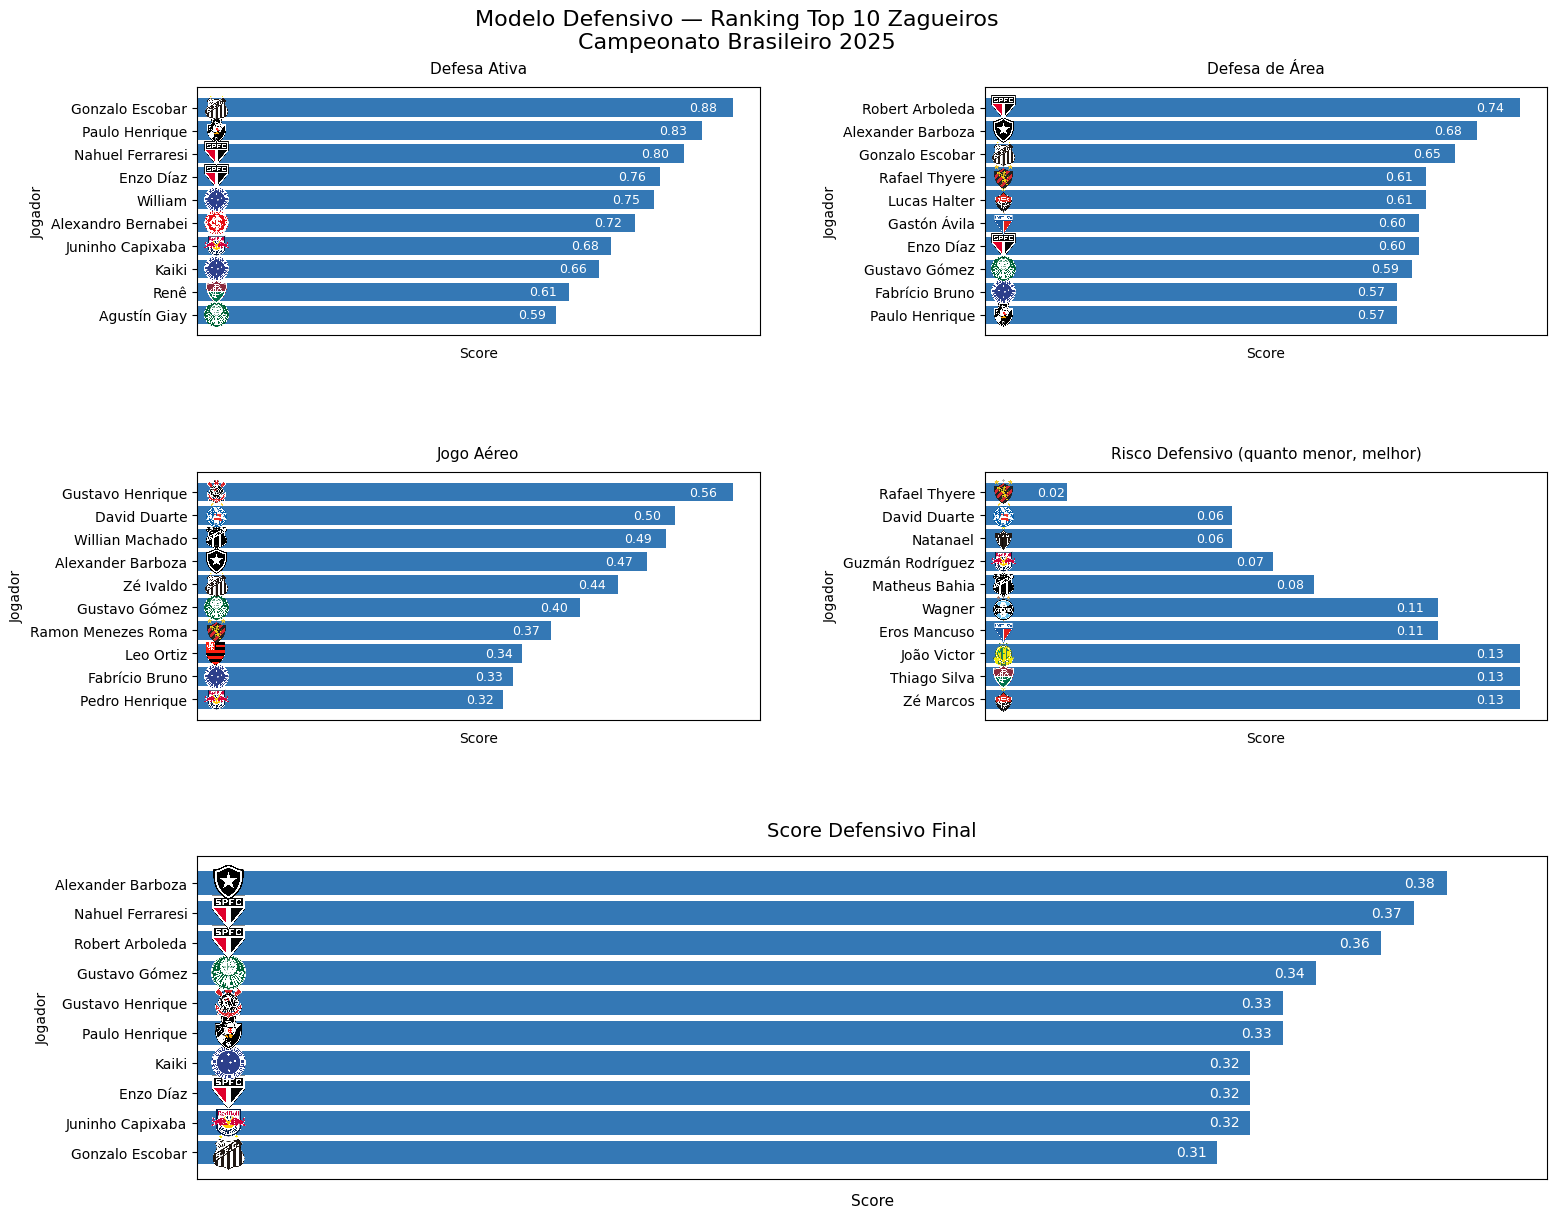

In [64]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

'''
Para deixar o gráfico visualmente intuitivo, escolhemos por utilizar
o arquivo '.png' vetorizado do escudo de cada time que iremos exibir no gráfico.
'''

ESCUDOS = {
    'Atlético Mineiro': '/content/drive/MyDrive/Colab Notebooks/projeto_final_footure/assets/escudo_br25/Atletico.png',
    'Bahia': '/content/drive/MyDrive/Colab Notebooks/projeto_final_footure/assets/escudo_br25/Bahia.png',
    'Botafogo (RJ)': '/content/drive/MyDrive/Colab Notebooks/projeto_final_footure/assets/escudo_br25/Botafogo.png',
    'Ceará': '/content/drive/MyDrive/Colab Notebooks/projeto_final_footure/assets/escudo_br25/Ceara.png',
    'Corinthians': '/content/drive/MyDrive/Colab Notebooks/projeto_final_footure/assets/escudo_br25/Corinthians.png',
    'Cruzeiro': '/content/drive/MyDrive/Colab Notebooks/projeto_final_footure/assets/escudo_br25/Cruzeiro.png',
    'Flamengo': '/content/drive/MyDrive/Colab Notebooks/projeto_final_footure/assets/escudo_br25/Flamengo.png',
    'Fluminense': '/content/drive/MyDrive/Colab Notebooks/projeto_final_footure/assets/escudo_br25/Fluminense.png',
    'Fortaleza': '/content/drive/MyDrive/Colab Notebooks/projeto_final_footure/assets/escudo_br25/Fortaleza.png',
    'Grêmio': '/content/drive/MyDrive/Colab Notebooks/projeto_final_footure/assets/escudo_br25/Gremio.png',
    'Internacional': '/content/drive/MyDrive/Colab Notebooks/projeto_final_footure/assets/escudo_br25/Internacional.png',
    'Mirassol': '/content/drive/MyDrive/Colab Notebooks/projeto_final_footure/assets/escudo_br25/Mirassol.png',
    'Palmeiras': '/content/drive/MyDrive/Colab Notebooks/projeto_final_footure/assets/escudo_br25/Palmeiras.png',
    'São Paulo': '/content/drive/MyDrive/Colab Notebooks/projeto_final_footure/assets/escudo_br25/Sao_Paulo.png',
    'Sport Recife': '/content/drive/MyDrive/Colab Notebooks/projeto_final_footure/assets/escudo_br25/Sport.png',
    'RB Bragantino': '/content/drive/MyDrive/Colab Notebooks/projeto_final_footure/assets/escudo_br25/Bragantino.png',
    'Vasco da Gama': '/content/drive/MyDrive/Colab Notebooks/projeto_final_footure/assets/escudo_br25/Vasco.png',
    'Santos': '/content/drive/MyDrive/Colab Notebooks/projeto_final_footure/assets/escudo_br25/Santos.png',
    'Vitória': '/content/drive/MyDrive/Colab Notebooks/projeto_final_footure/assets/escudo_br25/Vitoria.png',
}

# Função para Adicionar o escudo como design estratégico
def add_escudo(ax, y, squad, zoom=0.035, offset_x=0.02):
    if squad not in ESCUDOS:
        return
    try:
        img = plt.imread(ESCUDOS[squad])
        imagebox = OffsetImage(img, zoom=zoom)
        ab = AnnotationBbox(
            imagebox,
            (offset_x, y),
            xycoords='data',
            frameon=False,
            box_alignment=(0.5, 0.5)
        )
        ax.add_artist(ab)
    except Exception as e:
        print(f"Erro ao carregar escudo de {squad}: {e}")

# Definimos os Eixos do Gráfico e Dividimos a Plotagem em Grids de exibição na tela
fig = plt.figure(figsize=(18, 13))
grid = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1.3], hspace=0.5, wspace=0.4)

eixos = [
    fig.add_subplot(grid[0, 0]),
    fig.add_subplot(grid[0, 1]),
    fig.add_subplot(grid[1, 0]),
    fig.add_subplot(grid[1, 1])
]

# Plotamos os Scores Secundários no Topo (Eixos 2x2), por estética
scores_secundarios = {
    'Score_Defesa_Ativa': 'Defesa Ativa',
    'Score_Defesa_Area': 'Defesa de Área',
    'Score_Jogo_Aereo': 'Jogo Aéreo',
    'Score_Risco': 'Risco Defensivo (quanto menor, melhor)'
}

# Distribuímos os valores aos seus respectivos itens e ordenamento (e invertemos a visualização do Risco)
for ax, (col, label) in zip(eixos, scores_secundarios.items()):
    ascending = (col == 'Score_Risco') # quanto menor, melhor

    # Ordenando o melhor para aparecer no topo do gráfico
    top10 = ranking.sort_values(by=col, ascending=ascending).head(10)
    top10_plot = top10.iloc[::-1]

    # Distribuindo informações nas barras e traduzindo o Eixo Y 'Player' para 'Jogador'
    bars = ax.barh(top10_plot['Player'], top10_plot[col], color='#3478b5')
    ax.set_title(label, fontsize=11, pad=10)
    ax.set_ylabel('Jogador')

    # Mantemos o Eixo X ativo apenas como rótulo 'Score', pois a fins estéticos vamos escrever direto na barra
    ax.tick_params(axis='x', bottom=False, labelbottom=False)
    ax.set_xlabel('Score', fontsize=10, labelpad=8)

    max_val = top10_plot[col].max()
    ax.set_xlim(0, max_val * 1.05)

    for bar, (_, row) in zip(bars, top10_plot.iterrows()):
        width = bar.get_width()
        y_pos = bar.get_y() + bar.get_height() / 2
        ax.text(width * 0.97, y_pos, f'{width:.2f}', # Score do atleta direto na barra
                va='center', ha='right', fontsize=9, color='white')

        # Escudo adicionado
        add_escudo(ax, y_pos, row['Squad'], zoom=0.035, offset_x=max_val * 0.035)

# Gráfico Principal Exibido na parte Final para Destaque
ax_main = fig.add_subplot(grid[2, :])
top10 = ranking.sort_values(by='Score_Defensivo_Final', ascending=False).head(10)
top10_plot = top10.iloc[::-1]

bars = ax_main.barh(top10_plot['Player'], top10_plot['Score_Defensivo_Final'], color='#3478b5')
ax_main.set_title('Score Defensivo Final', fontsize=14, pad=15)
ax_main.set_ylabel('Jogador')

# Mantemos o Eixo X ativo apenas como rótulo
ax_main.tick_params(axis='x', bottom=False, labelbottom=False)
ax_main.set_xlabel('Score', fontsize=11, labelpad=10)

max_val = top10_plot['Score_Defensivo_Final'].max()
ax_main.set_xlim(0, max_val * 1.08)

# Iteramos as Barras para conter as informações necessárias do modelo, bem como personalização padrão
for bar, (_, row) in zip(bars, top10_plot.iterrows()):
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2
    ax_main.text(width * 0.99, y_pos, f'{width:.2f}',
                 va='center', ha='right', fontsize=10, color='white')
    add_escudo(ax_main, y_pos, row['Squad'], zoom=0.05, offset_x=max_val * 0.025)

# Título geral, Espaçamento e Personalização
fig.suptitle('Modelo Defensivo — Ranking Top 10 Zagueiros\nCampeonato Brasileiro 2025',
             fontsize=16, y=0.98)

fig.subplots_adjust(left=0.20, right=0.95, top=0.92, bottom=0.08)

#Exibição
plt.show()


*1.8. Conclusão*
> i. Podemos, de forma clara e objetiva, observar os índices correspondentes aos scores de cada atleta, bem como identificar seu nome e clube.  